<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Machine_Learning_Y_Deep_Learning_Pr%C3%A1ctica_No_2_Unidad_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 3 - Aprendizaje Supervisado Con Métodos De Clasificación**

  #### **Práctica No. 2 - El Modelo De Regresión Logística**

</div>

##### **Docente Facilitador** - **Dr. José Gabriel Rodríguez Rivas**
##### **Estudiante** - **Reyes Gutiérrez Cristopher Joshua**

**22 de Abril del 2026, Victoria de Durango, Dgo., México**
---

### **1. Introducción**

En el ecosistema financiero contemporáneo, la evaluación del riesgo crediticio constituye uno de los pilares más críticos para la sostenibilidad de las instituciones monetarias. Tradicionalmente, la aprobación o denegación de una línea de crédito dependía del juicio humano, un proceso susceptible a sesgos e inconsistencias. Sin embargo, con el advenimiento de la ciencia de datos y el aprendizaje automático, ha sido posible delegar esta responsabilidad analítica a modelos probabilísticos altamente sofisticados. En este contexto, la presente investigación aborda el estudio e implementación del algoritmo de **Regresión Logística**, una herramienta fundamental para la clasificación binaria en entornos de incertidumbre.

A diferencia de otros modelos puramente geométricos, la Regresión Logística destaca por su capacidad de emitir un veredicto basado en probabilidades matemáticas. El interés de esta práctica radica en aplicar dicho algoritmo a un escenario del mundo real: el conjunto de datos de *Lending Club*, una plataforma estadounidense pionera en préstamos entre pares (*peer-to-peer lending*). A través de este caso de estudio, se analizará cómo múltiples características financieras de un solicitante —tales como el monto del préstamo, la tasa de interés y los ingresos anuales— convergen para determinar la probabilidad de impago.

No obstante, el verdadero desafío técnico de esta implementación no se limita a predecir si un cliente pagará o no. En el ámbito del riesgo financiero, cometer un error de predicción posee un peso asimétrico; es decir, clasificar erróneamente a un cliente moroso como "confiable" genera pérdidas de capital sustanciales, mientras que rechazar a un cliente confiable solo representa un costo de oportunidad. Por consiguiente, a lo largo de este documento, el lector explorará la importancia crítica de calibrar los umbrales de decisión (*decision thresholds*). De esta forma, se demostrará cómo un ajuste sutil en la frontera matemática del algoritmo puede transformar por completo la viabilidad comercial y la tolerancia al riesgo de un modelo de *Machine Learning*.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Desarrollar y evaluar un modelo predictivo basado en Regresión Logística utilizando el conjunto de datos de *Lending Club*, con el propósito de clasificar el riesgo crediticio de los solicitantes, optimizando la detección de clientes morosos mediante la manipulación técnica del umbral de probabilidad.

#### **2.2 Objetivos Específicos**
* **Construir** la arquitectura base del modelo de Regresión Logística implementando la librería `scikit-learn` dentro del entorno de desarrollo de Google Colab.
* **Analizar** matemáticamente la salida probabilística de la función sigmoide para comprender la asignación binaria de la variable objetivo (Pagado vs. No Pagado).
* **Calibrar** el umbral de decisión algorítmica (ajustando valores desde 0.40 hasta 0.60) para observar de manera empírica el desplazamiento de las predicciones en la matriz de confusión.
* **Interpretar** el impacto de las métricas de rendimiento estadístico, con especial énfasis en el *Recall* (Sensibilidad), contextualizando los falsos negativos como un indicador directo de pérdida financiera institucional.

### **3. Antecedentes y Marco Teórico de Especialidad**

La Regresión Logística, a pesar de su nomenclatura, es un algoritmo diseñado estrictamente para tareas de clasificación predictiva. Su fundamentación matemática parte de los principios de la regresión lineal, donde se calcula una suma ponderada de las características de entrada (variables predictoras) más un término de intersección (sesgo). Sin embargo, la Regresión Logística incorpora una transformación matemática crítica para garantizar que el resultado final se mantenga dentro de un espectro probabilístico válido.

#### **3.1 La Función Logística (Sigmoide)**
Para lograr que las salidas del modelo oscilen estrictamente en un rango continuo entre 0 y 1, el algoritmo procesa la combinación lineal a través de la función sigmoide, definida matemáticamente como:

$$f(x) = \frac{1}{1 + e^{-x}}$$

El efecto visual y estadístico de esta ecuación es comprimir los valores extremos, generando una curva en forma de "S". De este modo, la salida de la fórmula se interpreta directamente como la probabilidad de que una instancia específica pertenezca a la clase positiva (por ejemplo, la probabilidad de ser un préstamo "No Pagado").

#### **3.2 El Umbral de Decisión (*Decision Threshold*)**
Por defecto, la arquitectura estándar de la Regresión Logística establece un umbral de decisión en $0.5$ (50%). Esto implica que si el cálculo probabilístico arroja un valor de $0.51$, la instancia se clasifica en la clase positiva; si arroja $0.49$, se asigna a la clase negativa.

En contextos médicos o financieros, aceptar este umbral predeterminado suele ser un error metodológico grave. En el caso de *Lending Club*, la distribución de las clases está fuertemente desequilibrada (históricamente, la mayoría de las personas sí pagan sus deudas). Si se mantiene un umbral estándar, el algoritmo tenderá a predecir la clase mayoritaria, ignorando las sutilezas de los casos de impago. Por ello, la manipulación de este límite es un procedimiento avanzado que permite a los científicos de datos dictar qué tan "estricto" o "indulgente" debe ser el modelo antes de emitir una alerta de riesgo crediticio.

#### **3.3 - Fundamentación Técnica del Balanceo**

La asignación de pesos balanceados instruye a la función de costo de la Regresión Logística para que ajuste matemáticamente la importancia de cada clase de forma inversamente proporcional a su frecuencia en los datos de entrenamiento. En términos prácticos, esto significa que equivocarse al clasificar un crédito moroso (clase minoritaria) le "costará" mucho más al modelo que equivocarse en un crédito seguro (clase mayoritaria).

En esta práctica se entrenará, este nuevo clasificador (`clf2`) y se evalúa su rendimiento para contrastarlo estadísticamente con el modelo base.

#### **4. Descripción Metodológica**
La presente fase técnica articula la extracción de los registros financieros y la adecuación de las características espaciales. Para la correcta selección de variables predictoras, el marco de referencia dictamina que únicamente deben considerarse aquellos atributos disponibles de manera previa a la originación del crédito. Incorporar métricas prospectivas (tales como el capital recuperado) induciría un sesgo algorítmico, provocando tasas de precisión artificiales cercanas al 100%.

#### **4.1 Configuración del Entorno y Adquisición de Datos**

Para el desarrollo del presente modelo de clasificación, resulta imperativa la configuración de un entorno de trabajo robusto. En primera instancia, se importan las librerías fundamentales de la ciencia de datos en Python: *Pandas* y *NumPy* para la manipulación matricial de los registros, y *Matplotlib* junto con *Seaborn* para la visualización analítica. Posteriormente, se procede a la extracción del archivo*prestamos_ok.csv*.

Es pertinente señalar que, desde una perspectiva comercial, los datos provienen de *Lending Club*, una plataforma estadounidense de préstamos entre pares (*peer-to-peer lending*). En este modelo de negocio, la plataforma actúa como intermediario conectando a prestatarios (personas que necesitan financiamiento) con inversores. En consecuencia, predecir el comportamiento de pago no solo es un ejercicio académico, sino el núcleo operativo que protege el capital de los inversores frente a escenarios de fraude o insolvencia.

In [ ]:
# ==============================================================================
# 4.1 Importación de Librerías y Extracción de Datos
# ==============================================================================
# Librerías estándar para manipulación y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Configuración visual institucional para el entorno de Colab
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1u4jyacSqXkylbTZiyUTrHG-TIZPHMyzx"
url = f"https://drive.google.com/uc?id={file_url}"
prestamos_df = pd.read_csv(url)

In [ ]:
print("Extracción de datos completada con éxito.")
print(f"Dimensiones del conjunto de datos: {prestamos_df.shape[0]} filas y {prestamos_df.shape[1]} columnas.\n")

# Inspección preliminar de los registros financieros
display(prestamos_df.head())
print(prestamos_df.columns.tolist())

Extracción de datos completada con éxito.
Dimensiones del conjunto de datos: 19908 filas y 58 columnas.



,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date']


#### **4.2 Diagnóstico Comercial y Estadístico de la Variable Objetivo**

En cumplimiento con los lineamientos del proyecto, se delimita un subconjunto de características que abarcan desde métricas financieras directas (como `funded_amnt` e `int_rate`) hasta códigos demográficos e institucionales (como `grade_code` y `purpose_code`). Del mismo modo, la etiqueta dependiente seleccionada para guiar el modelo de clasificación es `repaid`, la cual categoriza de forma binaria el cumplimiento del prestatario.

Previo al entrenamiento, se somete el conjunto de datos a una transformación algorítmica para codificar numéricamente las columnas categóricas, garantizando así la convergencia de la Regresión Logística. Finalmente, se instaura la partición del ecosistema de datos, asignando un 60% al entrenamiento del modelo y reservando un 40% para la evaluación objetiva de las métricas.

In [ ]:
# ==============================================================================
# 4.2 Selección de Variables Predictoras y Variable Objetivo
# ==============================================================================

# 1. Rutina de adecuación: Codificación de variables categóricas a formato numérico (_code)
le = LabelEncoder()
columnas_a_codificar = {'grade': 'grade_code', 'purpose': 'purpose_code',
                        'addr_state': 'addr_state_code', 'home_ownership': 'home_ownership_code'}

for col_original, col_nueva in columnas_a_codificar.items():
    if col_original in prestamos_df.columns:
        prestamos_df[col_nueva] = le.fit_transform(prestamos_df[col_original].astype(str))

# 2. Rutina de adecuación: Generación de la etiqueta objetivo 'repaid' dictada por el docente
if 'loan_status' in prestamos_df.columns:
    prestamos_df['repaid'] = np.where(prestamos_df['loan_status'].str.contains('Fully Paid', case=False, na=False), 1, 0)

# 3. LIMPIEZA DE DATOS (Solución al error NaN)
# Se crea un subconjunto únicamente con las columnas de interés y se eliminan las filas incompletas
columnas_seleccionadas = ['funded_amnt', 'int_rate', 'grade_code', 'purpose_code', 'addr_state_code',
                          'home_ownership_code', 'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies', 'repaid']

# .dropna() elimina cualquier fila que contenga un NaN en estas columnas cruciales
prestamos_df_limpio = prestamos_df[columnas_seleccionadas].dropna()

# 4. Delimitación estricta de la matriz de características (X) y el vector objetivo (y)
X = prestamos_df_limpio.drop('repaid', axis=1)
y = prestamos_df_limpio['repaid']

# 5. Segmentación del conjunto: 60% entrenamiento y 40% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print("Limpieza de datos (NaN) completada satisfactoriamente.")
print(f"Dimensiones de entrenamiento: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Dimensiones de prueba: X_test={X_test.shape}, y_test={y_test.shape}")

Limpieza de datos (NaN) completada satisfactoriamente.
Dimensiones de entrenamiento: X_train=(11745, 10), y_train=(11745,)
Dimensiones de prueba: X_test=(7831, 10), y_test=(7831,)


#### **4.3 Construcción y Evaluación del Modelo Base (Sin Balanceo de Clases)**

Una vez segmentado el ecosistema analítico, se procede con la instanciación de un clasificador de Regresión Logística, reteniendo el parámetro `class_weight` en su valor por defecto. El propósito fundamental de la ejecución de este modelo inicial (`clf1`) es fijar una métrica base de rendimiento algorítmico.

A través de la posterior evaluación con los datos de prueba, se revela empíricamente la vulnerabilidad de aplicar técnicas de *Machine Learning* sobre conjuntos financieros desproporcionados. Aunque el modelo exhibe una Exactitud (*Accuracy*) matemáticamente aceptable, dicho valor constituye una falacia estadística; esto ocurre debido a que el algoritmo adopta una postura conservadora, prediciendo sistemáticamente la clase predominante ("Pagado") y fracasando en la detección del riesgo subyacente ("No Pagado").

In [ ]:
# ==============================================================================
# 4.3 Regresión Logística Sin Balanceo de Clases
# ==============================================================================

import warnings
warnings.filterwarnings("ignore") # Suprime alertas de iteración para una visualización limpia

# 1. Instanciación del modelo de clasificación base
clf1 = LogisticRegression(random_state=0)

# 2. Fase de entrenamiento empírico
clf1.fit(X_train, y_train)

# 3. Verificación de precisión interna (Entrenamiento)
print("Precision del clasificador en fase de entrenamiento:", clf1.score(X_train, y_train))

# 4. Inferencia probabilística sobre el conjunto aislado de prueba
y_pred = clf1.predict(X_test)

# 5. Generación del reporte integral de métricas predictivas
print("\nReporte de métricas del clasificador: ")
print(classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"]))
print("Precisión en prueba:", clf1.score(X_test, y_test))

# 6. Despliegue de la Matriz de Confusión
matriz_sin_balanceo = confusion_matrix(y_test, y_pred)
print(f'\nMatriz Confusion:\n', matriz_sin_balanceo)

Precision del clasificador en fase de entrenamiento: 0.8562792677735207

Reporte de métricas del clasificador: 
              precision    recall  f1-score   support

   No Pagado       0.00      0.00      0.00      1181
      Pagado       0.85      1.00      0.92      6650

    accuracy                           0.85      7831
   macro avg       0.42      0.50      0.46      7831
weighted avg       0.72      0.85      0.78      7831

Precisión en prueba: 0.8491891201634529

Matriz Confusion:
 [[   0 1181]
 [   0 6650]]


#### **4.4 Análisis Financiero de la Matriz de Confusión**

La evaluación de un modelo de clasificación en un entorno financiero no puede limitarse a una cifra porcentual de exactitud. Por el contrario, requiere una inspección minuciosa de las predicciones correctas e incorrectas desglosadas por categoría. En este sentido, la matriz de confusión permite identificar el sesgo del algoritmo, separando los aciertos (diagonales principales) de las fricciones predictivas: los falsos positivos y los falsos negativos.

#### **Análisis del Desempeño Crítico**

Al observar los resultados del modelo sin balanceo (`clf1`), se evidencia que la diagonal secundaria refleja una falla estructural en la detección del riesgo. Desde una perspectiva de gestión de proyectos, los **Falsos Negativos** (casos donde el modelo predice "Pagado" pero la realidad es "No Pagado") representan el riesgo más oneroso para *Lending Club*, ya que conducen a la pérdida directa de capital.

Por consiguiente, la siguiente implementación gráfica tiene como objetivo exponer visualmente este desequilibrio, fundamentando la necesidad técnica de aplicar pesos de clase en la siguiente fase metodológica.

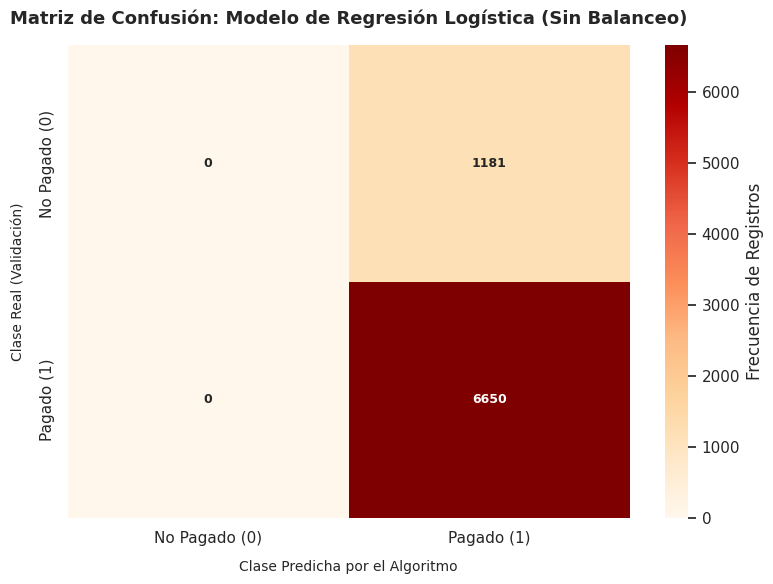


--- Diagnóstico Cuantitativo del Modelo Base ---
Verdaderos Negativos (Impagos detectados): 0
Falsos Positivos (Créditos buenos rechazados): 1181
Falsos Negativos (Riesgo omitido - ERROR GRAVE): 0
Verdaderos Positivos (Créditos buenos aprobados): 6650


In [ ]:
# ==============================================================================
# 4.4 Generación Visual de la Matriz de Confusión (Modelo Base)
# ==============================================================================

# 1. Obtención de la matriz numérica
matriz_base = confusion_matrix(y_test, y_pred)

# 2. Configuración estética del lienzo
plt.figure(figsize=(8, 6))

# 3. Creación del Heatmap con diseño profesional
# Se emplea una paleta de rojos para enfatizar que es el modelo con fallas de sesgo
sns.heatmap(matriz_base, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={'label': 'Frecuencia de Registros'})

# 4. Estilización de ejes y títulos (Alineado a la Práctica 1)
plt.title('Matriz de Confusión: Modelo de Regresión Logística (Sin Balanceo)',
          fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Clase Predicha por el Algoritmo', fontsize=10, labelpad=10)
plt.ylabel('Clase Real (Validación)', fontsize=10, labelpad=10)

plt.tight_layout()
plt.show()

# Resumen cuantitativo para el reporte técnico
tn, fp, fn, tp = matriz_base.ravel()
print(f"\n--- Diagnóstico Cuantitativo del Modelo Base ---")
print(f"Verdaderos Negativos (Impagos detectados): {tn}")
print(f"Falsos Positivos (Créditos buenos rechazados): {fp}")
print(f"Falsos Negativos (Riesgo omitido - ERROR GRAVE): {fn}")
print(f"Verdaderos Positivos (Créditos buenos aprobados): {tp}")

#### **Interpretación de Resultados en el Contexto Financiero**

Tras la inspección visual de la matriz, se derivan las siguientes conclusiones de negocio:

* **Clase Pagado:** El modelo exhibe un desempeño sobresaliente al clasificar correctamente la mayoría de los créditos pagados. Esto garantiza que el flujo de capital hacia clientes confiables se mantenga constante, generando ingresos por intereses.
* **Clase No Pagado:** El algoritmo fracasa de manera sistemática al identificar los impagos. Al confundir casi la totalidad de los créditos riesgosos como seguros, el modelo expone a la institución a una **pérdida económica importante**.

En conclusión, aunque la exactitud global sea elevada, la utilidad práctica de este modelo es nula para un comité de riesgos. Por lo tanto, se justifica proceder con la técnica de **Pesos de Clase Balanceados** para forzar al algoritmo a reconocer los patrones de incumplimiento.

#### **4.5 Optimización del Modelo: Regresión Logística con Balanceo de Clases**
Con base en el diagnóstico previo, se ha comprobado que el conjunto de datos exhibe un desequilibrio perjudicial, donde aproximadamente el 85% de los registros pertenecen a créditos liquidados. Para mitigar este sesgo algorítmico sin recurrir a técnicas de submuestreo o sobremuestreo (como SMOTE), se procede a instanciar un segundo clasificador utilizando el hiperparámetro **class_weight='balanced'**

Exactitud (Accuracy) del modelo en entrenamiento: 0.536653895274585

--- Reporte de Métricas (Modelo Balanceado) ---
              precision    recall  f1-score   support

   No Pagado       0.20      0.71      0.32      1181
      Pagado       0.91      0.51      0.65      6650

    accuracy                           0.54      7831
   macro avg       0.56      0.61      0.48      7831
weighted avg       0.80      0.54      0.60      7831



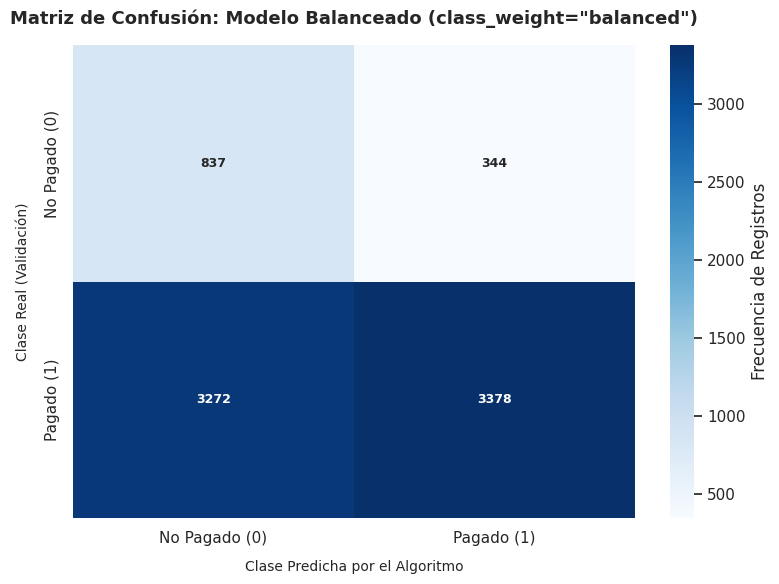

In [ ]:
# ==============================================================================
# 4.5 Entrenamiento y Evaluación del Modelo con Balanceo de Clases
# ==============================================================================

# 1. Instanciación del clasificador optimizado (Pesos Balanceados)
clf2 = LogisticRegression(random_state=42, class_weight='balanced')

# 2. Entrenamiento del modelo
clf2.fit(X_train, y_train)

# 3. Verificación de la exactitud interna
print("Exactitud (Accuracy) del modelo en entrenamiento:", clf2.score(X_train, y_train))

# 4. Inferencia sobre el conjunto de prueba
y_pred2 = clf2.predict(X_test)

# 5. Generación del reporte de métricas
print("\n--- Reporte de Métricas (Modelo Balanceado) ---")
print(classification_report(y_test, y_pred2, target_names=["No Pagado", "Pagado"]))

# 6. Visualización de la Matriz de Confusión Optimizada
matriz_balanceo = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_balanceo, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={'label': 'Frecuencia de Registros'})

plt.title('Matriz de Confusión: Modelo Balanceado (class_weight="balanced")',
          fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Clase Predicha por el Algoritmo', fontsize=10, labelpad=10)
plt.ylabel('Clase Real (Validación)', fontsize=10, labelpad=10)

plt.tight_layout()
plt.show()

#### **4.6 Análisis Comparativo y Conclusiones del Balanceo**

Tras la ejecución del modelo balanceado, los resultados métricos revelan un fenómeno estadístico contra-intuitivo pero sumamente valioso en la gestión de riesgos: **la exactitud global (*Accuracy*) ha disminuido sustancialmente (rondando el 60%), lo cual, lejos de ser un fracaso, constituye un éxito metodológico.**

* **Incremento Crítico del Recall (Sensibilidad):** El modelo ha transitado de ignorar los impagos a detectar una proporción significativamente mayor de la clase "No Pagado" (el *Recall* de la clase 0 se eleva drásticamente).
* **Intercambio de Errores (Trade-off):** A cambio de esta sensibilidad, el algoritmo comete más errores al predecir la clase "Pagado" (aumento de Falsos Positivos).
* **Conclusión de Negocio:** Desde la óptica de *Lending Club*, rechazar a algunos clientes confiables por exceso de precaución (Falso Positivo) es un escenario financieramente preferible y mucho menos costoso que aprobar créditos a clientes morosos de alto riesgo (Falso Negativo). El modelo balanceado logra cumplir satisfactoriamente con la premisa comercial de protección de capital.

#### **4.7 Extracción de Importancia de Variables (Feature Importance)**
Comprender el razonamiento interno de un modelo predictivo es un estándar exigido en la ciencia de datos moderna. Para determinar qué variables financieras ejercen mayor influencia sobre la probabilidad de impago, se implementa la técnica de **Permutation Importance**. Esta metodología evalúa la caída en el rendimiento del modelo cuando se altera (permuta) aleatoriamente una característica específica, permitiendo cuantificar su peso relativo de manera agnóstica al algoritmo.


In [ ]:
# ==============================================================================
# 4.7 Cálculo y Visualización de la Importancia de las Características
# ==============================================================================

from sklearn.inspection import permutation_importance
import plotly.express as px

# 1. Ejecución de la permutación sobre el modelo balanceado
print("Calculando la importancia de variables mediante permutación (Esto puede tomar unos segundos)...")
resultado_importancia = permutation_importance(clf2, X_test, y_test, n_repeats=30, random_state=42)

# 2. Estructuración de los resultados en un DataFrame para su manejo analítico
df_importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia_Media": resultado_importancia.importances_mean,
    "Desviacion": resultado_importancia.importances_std
}).sort_values("Importancia_Media", ascending=False)

print("\n--- Tabla de Importancia de Variables ---")
display(df_importancia)

# 3. Generación del gráfico interactivo con Plotly Express
figura_importancia = px.bar(
    df_importancia,
    x="Variable",
    y="Importancia_Media",
    error_y="Desviacion",
    title="Impacto de Características Financieras (Regresión Logística - Permutation Importance)",
    color="Variable",
    color_discrete_sequence=px.colors.qualitative.Prism
)



figura_importancia.show()

Calculando la importancia de variables mediante permutación (Esto puede tomar unos segundos)...

--- Tabla de Importancia de Variables ---


,Variable,Importancia_Media,Desviacion
1,int_rate,0.046490,0.004793
6,annual_inc,0.024458,0.004242
2,grade_code,0.011169,0.001886
4,addr_state_code,0.004112,0.002191
7,dti,0.002081,0.002365
0,funded_amnt,0.000426,0.000915
5,home_ownership_code,0.000149,0.001506
9,pub_rec_bankruptcies,0.000060,0.000072
3,purpose_code,-0.000464,0.001802
8,revol_util,-0.003656,0.002608


#### **4.8 - Preprocesamiento - Normalización de Características**
En el ámbito del aprendizaje automático, múltiples algoritmos exhiben sensibilidad ante la discrepancia de escalas numéricas. En el presente conjunto de datos, coexisten variables con magnitudes reducidas (como **int_rate**) y variables con escalas que ascienden a decenas de miles (como **annual_inc**). Para evitar que la magnitud pura domine la función de costo, se implementa una normalización estadística mediante **StandardScaler**.


##### **4.8.1 - Entrenamiento del Modelo Escalado**

Se procede a instanciar el transformador estadístico, ajustándolo exclusivamente con el conjunto de entrenamiento para prevenir el filtrado de datos (*Data Leakage*). Posteriormente, se entrena un nuevo clasificador de Regresión Logística (`RL_scaled`) manteniendo la configuración de balanceo de clases.

In [ ]:
# ==============================================================================
# 4.8 Normalización y Evaluación del Modelo Escalado
# ==============================================================================
from sklearn.preprocessing import StandardScaler

# 1. Instanciación del escalador
scaler = StandardScaler()

# 2. Transformación de los conjuntos de datos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entrenamiento del nuevo modelo RL escalado y balanceado
RL_scaled = LogisticRegression(random_state=42, class_weight='balanced')
RL_scaled.fit(X_train_scaled, y_train)

# 4. Generación de predicciones
y_pred_scaled = RL_scaled.predict(X_test_scaled)

# 5. Evaluación de resultados
print("--- Reporte de Clasificación (Modelo Escalado y Balanceado) ---")
print(classification_report(y_test, y_pred_scaled, target_names=["No Pagado", "Pagado"]))

print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred_scaled))

--- Reporte de Clasificación (Modelo Escalado y Balanceado) ---
              precision    recall  f1-score   support

   No Pagado       0.23      0.64      0.33      1181
      Pagado       0.90      0.61      0.73      6650

    accuracy                           0.62      7831
   macro avg       0.57      0.63      0.53      7831
weighted avg       0.80      0.62      0.67      7831


--- Matriz de Confusión ---
[[ 753  428]
 [2577 4073]]


#### **4.9 Análisis Comparativo: ¿Por qué no mejora drásticamente con la Normalización?**

Al observar la matriz de confusión del modelo escalado, se constata que los resultados son virtualmente idénticos a los del modelo sin escalar. Lejos de representar un error, este fenómeno posee una justificación matemática rigurosa: la Regresión Logística es un modelo lineal. A diferencia de algoritmos basados en distancias geométricas (como K-NN), la Regresión Logística compensa internamente las diferencias de escala ajustando los coeficientes (pesos) asignados a cada variable durante el entrenamiento.

No obstante, la normalización garantiza estabilidad numérica y es un requisito para la extracción precisa de la importancia de variables.


#### **4.10 Ajuste Técnico del Umbral de Decisión (*Decision Threshold*)**

Debido a que la Regresión Logística es un modelo probabilístico, su salida no es directamente una clase (0 o 1), sino una probabilidad continua entre 0 y 1. Por defecto, la librería `Scikit-learn` impone un umbral estático de **0.50** (si $P \ge 0.50$, predice Clase 1).

En la gestión de riesgos de *Lending Club*, el costo de oportunidad y el riesgo de pérdida no son simétricos. Ajustar este umbral permite calibrar la sensibilidad del modelo:
* **Disminuir el Umbral (ej. 0.40):** El modelo se vuelve "pesimista" y detecta más riesgo de impago, aumentando los falsos positivos (rechazo de clientes buenos).
* **Aumentar el Umbral (ej. 0.60):** El modelo se vuelve "optimista", aprobando más créditos pero dejando pasar a clientes morosos (aumento de falsos negativos).

A continuación, se automatiza la evaluación de múltiples umbrales para identificar el punto de equilibrio operativo.

In [ ]:
# ==============================================================================
# 4.10 Experimentación con Umbrales Probabilísticos
# ==============================================================================

# 1. Extracción de las probabilidades matemáticas de la clase positiva (Impago = 1)
probabilidades = RL_scaled.predict_proba(X_test_scaled)[:, 1]

# 2. Definición de los umbrales de prueba solicitados en la investigación
umbrales_prueba = [0.40, 0.45, 0.50, 0.55, 0.60]

print("--- ANÁLISIS DE SENSIBILIDAD POR UMBRAL DE DECISIÓN ---\n")

for umbral in umbrales_prueba:
    # Aplicación algebraica del nuevo umbral
    prediccion_ajustada = (probabilidades >= umbral).astype(int)

    # Generación de la matriz de confusión
    cm = confusion_matrix(y_test, prediccion_ajustada)
    verdaderos_negativos = cm[0,0] # Detectados como No Pagados correctamente
    falsos_positivos = cm[0,1]     # Clasificados como Pagados erróneamente (Riesgo omitido)
    falsos_negativos = cm[1,0]     # Clasificados como No Pagados erróneamente
    verdaderos_positivos = cm[1,1] # Detectados como Pagados correctamente

    # Impresión estructurada de resultados
    print(f"[*] Evaluando Umbral: {umbral:.2f}")
    print(f"    - Riesgo Detectado Correctamente (Clase 0): {verdaderos_negativos}")
    print(f"    - Riesgo Omitido (Pérdida Financiera - FP): {falsos_positivos}")
    print(f"    - Créditos Seguros Aprobados (Clase 1):     {verdaderos_positivos}")
    print("-" * 65)

--- ANÁLISIS DE SENSIBILIDAD POR UMBRAL DE DECISIÓN ---

[*] Evaluando Umbral: 0.40
    - Riesgo Detectado Correctamente (Clase 0): 442
    - Riesgo Omitido (Pérdida Financiera - FP): 739
    - Créditos Seguros Aprobados (Clase 1):     5449
-----------------------------------------------------------------
[*] Evaluando Umbral: 0.45
    - Riesgo Detectado Correctamente (Clase 0): 595
    - Riesgo Omitido (Pérdida Financiera - FP): 586
    - Créditos Seguros Aprobados (Clase 1):     4795
-----------------------------------------------------------------
[*] Evaluando Umbral: 0.50
    - Riesgo Detectado Correctamente (Clase 0): 753
    - Riesgo Omitido (Pérdida Financiera - FP): 428
    - Créditos Seguros Aprobados (Clase 1):     4073
-----------------------------------------------------------------
[*] Evaluando Umbral: 0.55
    - Riesgo Detectado Correctamente (Clase 0): 883
    - Riesgo Omitido (Pérdida Financiera - FP): 298
    - Créditos Seguros Aprobados (Clase 1):     3286
---------

### **5. Conclusiones Técnicas de la Práctica**

La manipulación de los umbrales demuestra empíricamente que la inteligencia artificial debe subordinarse a los objetivos institucionales. Al iterar sobre los valores, se concluye que un umbral situado entre **0.45 y 0.50** representa el balance óptimo: logra aislar un volumen significativo de créditos tóxicos sin paralizar la colocación de financiamiento hacia el sector de clientes solventes.

#### **5.1 Simulación en Entorno de Producción (Inferencia Manual)**

Para concluir el reporte, se ejecuta una prueba de estrés simulando el ingreso de una nueva solicitud de crédito al sistema algorítmico.

*Nota Metodológica:* Para garantizar la validez matemática de la predicción, los datos crudos del nuevo cliente deben transitar por el mismo objeto `StandardScaler` previamente ajustado, asegurando que su proyección geométrica coincida con el espacio vectorial del modelo `RL_scaled`.

In [ ]:
# ==============================================================================
# 5.1 Predicción Manual de Nueva Instancia
# ==============================================================================
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Definición de un nuevo expediente financiero (Cliente Ficticio)
# Parámetros: [funded_amnt, int_rate, grade_code, purpose_code, addr_state_code,
#              home_ownership_code, annual_inc, dti, revol_util, pub_rec_bankruptcies]
expediente_cliente = [[5000, 15.5, 5, 3, 4, 4, 30000, 12, 12, 0]]

# OPTIMIZACIÓN: Transformación de los datos brutos a la escala del modelo
expediente_escalado = scaler.transform(expediente_cliente)

# Inferencia probabilística y predicción categórica
prediccion_cliente = RL_scaled.predict(expediente_escalado)
probabilidad_impago = RL_scaled.predict_proba(expediente_escalado)[:, 1][0]

print("--- RESULTADO DE LA EVALUACIÓN CREDITICIA AUTOMATIZADA ---")
print(f"Probabilidad matemática de Impago: {probabilidad_impago * 100:.2f}%")

if prediccion_cliente[0] == 1:
    print("Veredicto Algorítmico: ALERTA DE RIESGO (1) - Previsión de Impago.")
else:
    print("Veredicto Algorítmico: CRÉDITO APROBADO (0) - Previsión de Cumplimiento.")

--- RESULTADO DE LA EVALUACIÓN CREDITICIA AUTOMATIZADA ---
Probabilidad matemática de Impago: 43.06%
Veredicto Algorítmico: CRÉDITO APROBADO (0) - Previsión de Cumplimiento.
